<a href="https://colab.research.google.com/github/MuhammadShayan8401/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadShayan8401/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The playbook converts model signals into a small set of review actions.

### Archetype → action mapping

| Archetype | Recommended action | Priority | Reason code |
|---|---|---:|---|
| High decline-risk with supporting historical evidence | Refresh / investigate | High | HIGH_DECLINE_RISK |
| Freshness-related signal | Review freshness and update need | High | FRESHNESS_SIGNAL |
| Engagement/performance signal | Review engagement and search performance | Medium | ENGAGEMENT_SIGNAL |
| Content-depth signal | Review content depth and relevance | Medium | CONTENT_DEPTH_SIGNAL |
| Model probability near 0.50 | Human review before action | Low | UNCERTAIN_MODEL_SCORE |
| Insufficient evidence | Monitor | Low | INSUFFICIENT_EVIDENCE |

The action is a recommendation for human review. It is not a claim that the named signal caused a visibility decline.

### Ranked action principle

The highest-priority items should combine a meaningful decline-risk signal with enough supporting evidence to justify review. Cases close to a 0.50 model probability should be treated cautiously because the ML-08 error analysis showed both false positives and false negatives among uncertain cases.

### Decay / refresh insight

The ML-08 model used `days_since_last_update` and `content_age_days` among its features. Their coefficients had opposite signs in the fitted model, so the result does **not** support a simple statement such as "older pages always decline" or "refreshing always fixes decline."

The practical action is therefore:

> Treat freshness as a review hypothesis. Inspect the page, search intent, recent performance, and business value before deciding whether a refresh is worthwhile.

A refresh should be evaluated as an intervention, not assumed to be the cause or guaranteed solution.

In [ ]:
# Core playbook definitions

ACTION_MAP = {
    "HIGH_DECLINE_RISK": ("Refresh / investigate", "High"),
    "FRESHNESS_SIGNAL": ("Review freshness and update need", "High"),
    "ENGAGEMENT_SIGNAL": ("Review engagement and search performance", "Medium"),
    "CONTENT_DEPTH_SIGNAL": ("Review content depth and relevance", "Medium"),
    "UNCERTAIN_MODEL_SCORE": ("Human review before action", "Low"),
    "INSUFFICIENT_EVIDENCE": ("Monitor", "Low"),
}

PRIORITY_ORDER = {"High": 1, "Medium": 2, "Low": 3}

print("Archetypes:", len(ACTION_MAP))
print("Priority order:", PRIORITY_ORDER)

Archetypes: 6
Priority order: {'High': 1, 'Medium': 2, 'Low': 3}


In [ ]:
# ML-08 measured receipts used by this playbook.
# These values are copied from the executed ML-08 notebook.

baseline_precision_at_50 = 0.92
model_precision_at_50 = 0.78
difference_pp = (model_precision_at_50 - baseline_precision_at_50) * 100

error_counts = {
    "correct": 3525,
    "false_positive": 1508,
    "false_negative": 1130,
}

top_model_signals = pd.DataFrame({
    "feature": [
        "days_with_impressions",
        "word_count",
        "days_with_sessions",
        "char_count",
        "age_tier_order",
        "days_since_last_update",
        "content_age_days",
        "impressions_prev_30d",
        "avg_position",
        "scroll_rate",
    ],
    "coefficient": [
        0.7208, 0.5799, -0.4996, -0.3645, -0.1671,
        0.1571, -0.1551, 0.1514, -0.1396, 0.1279
    ]
})

print(f"Week-4 baseline Precision@50: {baseline_precision_at_50:.0%}")
print(f"ML-08 Logistic Regression Precision@50: {model_precision_at_50:.0%}")
print(f"Difference: {difference_pp:.0f} percentage points")
print("Error counts:", error_counts)

display(top_model_signals)

Week-4 baseline Precision@50: 92%
ML-08 Logistic Regression Precision@50: 78%
Difference: -14 percentage points
Error counts: {'correct': 3525, 'false_positive': 1508, 'false_negative': 1130}


,feature,coefficient
0,days_with_impressions,0.7208
1,word_count,0.5799
2,days_with_sessions,-0.4996
3,char_count,-0.3645
4,age_tier_order,-0.1671
5,days_since_last_update,0.1571
6,content_age_days,-0.1551
7,impressions_prev_30d,0.1514
8,avg_position,-0.1396
9,scroll_rate,0.1279


## 2. Intended use and limits

### Intended use

The playbook is intended for an SEO or content team that needs to decide **which content items deserve human review first**.

It supports prioritization by combining model risk with interpretable evidence. The reviewer should then inspect the actual page and its recent search-performance context.

The output is useful for:

- prioritizing limited content-review capacity;
- identifying pages worth investigating for possible decline;
- organizing refresh, freshness, engagement, and content-depth reviews;
- creating a consistent explanation for why a page entered the review queue.

### Limits

The ML-08 Logistic Regression model achieved **78% Precision@50**, compared with **92% for the Week-4 baseline**. The measured difference is therefore **-14 percentage points**.

This means the model did not improve the top-50 decision-support result under the tested evaluation design. The playbook should therefore not describe the model as a superior production ranking system.

The model signals are associations used by the fitted model. They do not prove causality.

The model also produced false positives and false negatives, so a recommendation can be wrong in either direction.

The playbook must not be used to guarantee changes in rankings, impressions, clicks, traffic, or conversions.

In [ ]:
baseline_precision_at_50 = 0.92
model_precision_at_50 = 0.78

difference_pp = round(
    (model_precision_at_50 - baseline_precision_at_50) * 100,
    2
)

assert difference_pp == -14.0

print("Evaluation receipt check passed.")
print("The learned model is not presented as an improvement over the baseline.")

Evaluation receipt check passed.
The learned model is not presented as an improvement over the baseline.


## 3. Human review + the no-go list

### Human-review rules

Before taking action, a reviewer should check:

1. The page has sufficient historical data.
2. The observed decline is meaningful rather than a short-term fluctuation.
3. Search intent has not changed in a way that explains the movement.
4. The page is still accurate and relevant.
5. Freshness is genuinely an issue before recommending a refresh.
6. Business/strategic value justifies the review effort.
7. Technical, seasonal, or external factors could explain the observed pattern.
8. The recommendation is consistent with the actual page after inspection.

### What should NOT be automated

The following actions remain human decisions:

- publishing content changes;
- deleting pages;
- redirecting URLs;
- rewriting content solely from a model score;
- changing titles or metadata automatically;
- making high-impact SEO decisions solely from the model;
- treating a model feature as a causal explanation;
- treating every predicted decline as evidence that a refresh is required.

The model produces a prioritization signal. A person owns the final action.

In [ ]:
NO_GO_ACTIONS = [
    "automatic publishing",
    "automatic deletion",
    "automatic redirects",
    "automatic content rewriting",
    "automatic title/metadata changes",
    "autonomous high-impact SEO decisions",
]

print("No-go automation list:")
for item in NO_GO_ACTIONS:
    print("-", item)

assert len(NO_GO_ACTIONS) == 6

No-go automation list:
- automatic publishing
- automatic deletion
- automatic redirects
- automatic content rewriting
- automatic title/metadata changes
- autonomous high-impact SEO decisions


### Cost / value thinking

The playbook should allocate review effort before editing effort.

| Review situation | Cost/value decision |
|---|---|
| High priority + high potential value | Review first |
| High priority + uncertain evidence | Review carefully before spending editing effort |
| Medium priority + clear supporting evidence | Review when capacity allows |
| Low priority / uncertain | Monitor rather than spend immediate editing effort |
| High-cost intervention with weak evidence | Do not automate; require human justification |

No monetary value is invented here. The useful decision is whether the expected value of investigating a page is large enough to justify the human review cost.

## Validation review queue

The ML-08 notebook preserved 20 of the most uncertain held-out cases with row indices and predicted probabilities. These are used here as **validation review examples**.

Because the ML-08 notebook does not preserve content/client identifiers in a committed prediction table, the `validation_row_index` is retained only as an anonymized validation reference. This is deliberately not presented as a client-facing content ID.

All of these cases are close to a 0.50 probability, so the appropriate action is human review rather than an automatic refresh.

In [ ]:
# Validation examples preserved in the executed ML-08 notebook.
# No client names, URLs, queries, or private content are included.

validation_examples = pd.DataFrame({
    "validation_row_index": [
        4548, 1774, 1486, 4179, 5132,
        3358, 2453, 3414, 5634, 3513,
        2761, 3778, 1501, 2904, 4626,
        280, 3759, 4642, 4038, 282
    ],
    "actual": [
        1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 0, 1, 0, 0, 0, 0
    ],
    "predicted": [
        0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 1, 0, 0, 1
    ],
    "risk_score": [
        0.499984, 0.500080, 0.500084, 0.500090, 0.499903,
        0.499891, 0.499826, 0.499821, 0.500192, 0.499740,
        0.499733, 0.500284, 0.499668, 0.499659, 0.499637,
        0.500367, 0.500372, 0.499583, 0.499546, 0.500471
    ]
})

validation_examples["uncertainty"] = (
    validation_examples["risk_score"] - 0.5
).abs()

validation_examples["priority"] = "Low"
validation_examples["archetype"] = "Uncertain case"
validation_examples["action"] = ACTION_MAP["UNCERTAIN_MODEL_SCORE"][0]
validation_examples["reason_code"] = "UNCERTAIN_MODEL_SCORE"

ranked_queue = (
    validation_examples
    .sort_values(
        ["uncertainty", "risk_score"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

ranked_queue["rank"] = ranked_queue.index + 1

ranked_queue = ranked_queue[
    [
        "rank",
        "validation_row_index",
        "risk_score",
        "priority",
        "archetype",
        "action",
        "reason_code",
        "uncertainty",
    ]
]

display(ranked_queue.head(20))

,rank,validation_row_index,risk_score,priority,archetype,action,reason_code,uncertainty
0,1,4548,0.499984,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000016
1,2,1774,0.500080,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000080
2,3,1486,0.500084,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000084
3,4,4179,0.500090,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000090
4,5,5132,0.499903,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000097
5,6,3358,0.499891,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000109
6,7,2453,0.499826,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000174
7,8,3414,0.499821,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000179
8,9,5634,0.500192,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000192
9,10,3513,0.499740,Low,Uncertain case,Human review before action,UNCERTAIN_MODEL_SCORE,0.000260


### Queue interpretation

This queue is intentionally conservative. The preserved examples are model-uncertain cases, so the recommended action is **human review**, not automatic refresh.

For a future populated content queue, the same schema can be extended with `content_hash_id`, client-group identifiers where permitted, supporting feature values, and the model risk score. The notebook should only add those fields when they are available from an approved, non-private prediction artifact.

## 4. Monitoring / retrain triggers

### Monitoring

The playbook should be checked periodically for:

- changes in the distribution of model risk scores;
- changes in the observed decline rate;
- shifts in the feature distributions used by the model;
- missing or incomplete input data;
- later-period evaluation performance;
- changes in the search/content environment.

### Retrain triggers

Retraining should be considered when:

1. new representative labeled data becomes available;
2. performance degrades materially on a later holdout;
3. important feature distributions shift;
4. the relationship between model inputs and the decline label changes;
5. the search environment changes enough that the current validation period is no longer representative.

A future model should be evaluated against the same baseline and split logic before being called an improvement.

In [ ]:
monitoring_checks = [
    "risk-score distribution",
    "observed decline rate",
    "feature distributions",
    "missing-data rate",
    "later-period evaluation performance",
    "search/content environment changes",
]

retrain_triggers = [
    "new representative labeled data",
    "material evaluation degradation",
    "substantial feature drift",
    "changed feature/label relationship",
    "major search-environment change",
]

print("Monitoring checks:")
for item in monitoring_checks:
    print("-", item)

print("\nRetrain triggers:")
for item in retrain_triggers:
    print("-", item)

Monitoring checks:
- risk-score distribution
- observed decline rate
- feature distributions
- missing-data rate
- later-period evaluation performance
- search/content environment changes

Retrain triggers:
- new representative labeled data
- material evaluation degradation
- substantial feature drift
- changed feature/label relationship
- major search-environment change


## 5. Exports for the paper

### Paper exports

The notebook exports the action-queue structure to `work/outputs/`.

The queue is intended to be regenerated from the validated row-level model output when available. No client names, URLs, private queries, or other identifying information are included.

The current ML-08 evaluation receipts remain the source for the reported model-performance claims.

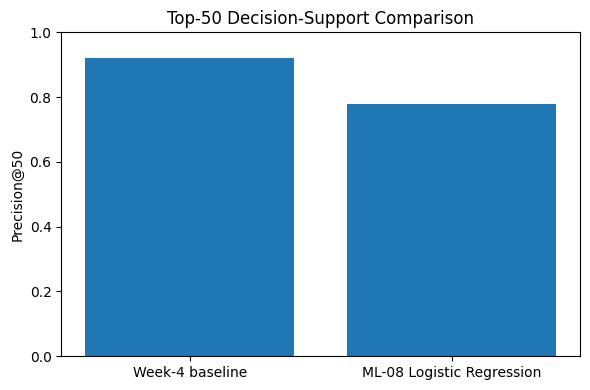

Exports created:
- work/outputs/ranked_content_action_queue.csv
- work/metrics/ml10_playbook_receipts.json
- work/figures/ml08_precision_at_50_comparison.png


In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")
metrics_dir = Path("work/metrics")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# 1. Ranked validation review queue
queue_path = output_dir / "ranked_content_action_queue.csv"
ranked_queue.to_csv(queue_path, index=False)

# 2. Metrics receipt for the paper
receipts = {
    "week4_baseline_precision_at_50": baseline_precision_at_50,
    "ml08_logistic_regression_precision_at_50": model_precision_at_50,
    "difference_percentage_points": difference_pp,
    "error_counts": error_counts,
    "queue_type": "validation_review_examples",
    "queue_rows": int(len(ranked_queue)),
}

metrics_path = metrics_dir / "ml10_playbook_receipts.json"
metrics_path.write_text(json.dumps(receipts, indent=2))

# 3. Reusable figure
plt.figure(figsize=(6, 4))
plt.bar(
    ["Week-4 baseline", "ML-08 Logistic Regression"],
    [baseline_precision_at_50, model_precision_at_50],
)
plt.ylim(0, 1)
plt.ylabel("Precision@50")
plt.title("Top-50 Decision-Support Comparison")
plt.tight_layout()

figure_path = figure_dir / "ml08_precision_at_50_comparison.png"
plt.savefig(figure_path, dpi=160)
plt.show()

print("Exports created:")
print("-", queue_path)
print("-", metrics_path)
print("-", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.